## What is Regression in Machine Learning?
Regression is a supervised machine learning technique used when the target variable (the output we want to predict) is continuous (numeric) rather than categorical.

It is about finding the relationship (mathematical function) between:

- `Independent Variables` (features, predictors, inputs, X): e.g., size of house, number of bedrooms, years of experience.
- `Dependent Variable` (target, output, Y): e.g., price of house, employee salary.

### Examples of Regression Problems

#### 1. House Price Prediction

- Input: Size (sq. ft), number of rooms, location.
- Output: House price in dollars.

#### 2. Stock Market Prediction

- Input: Previous stock prices, trading volume.
- Output: Next-day stock price.

#### 3. Medical Use Case

- Input: Age, BMI, blood pressure.
- Output: Patient’s blood sugar level.

#### 4. Weather Forecasting

- Input: Humidity, wind speed, past temperature.
- Output: Tomorrow’s temperature.

### Types of Regression Models
#### 1. Simple Linear Regression

Assumes a linear relationship between input and output.

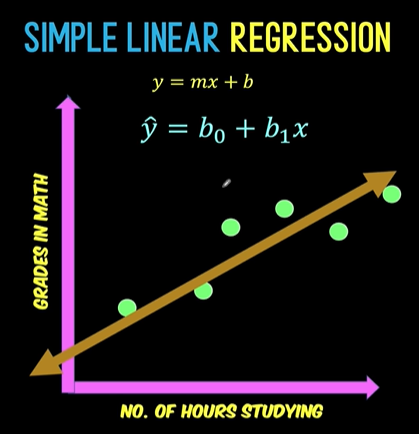 | 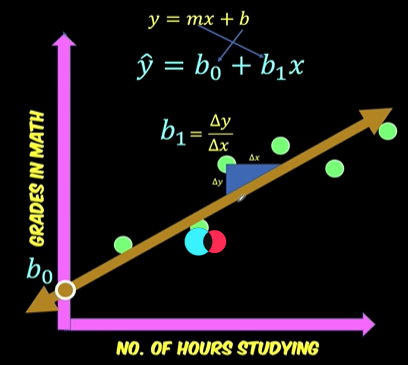

<table>
<tr>
<td>

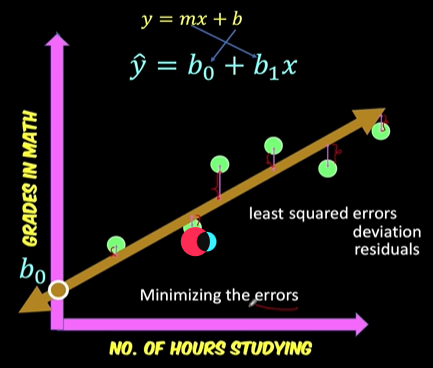

</td>
<td>

### Why “Squared”?
- If we just summed raw errors, **positive and negative would cancel out**.  
- **Squaring ensures all errors are positive.**  
- Also, squaring **penalizes larger errors more strongly**.  

</td>
</tr>
</table>


Least Squared Error is the method linear regression uses to find the best-fitting line by minimizing the sum of squared differences between actual and predicted values.

Equation: 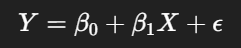

Where:

- Y = predicted output
- 𝛽0 = intercept (where the line crosses the y-axis)
- 𝛽1 = slope of the line/weight of the feature
- ϵ = error term



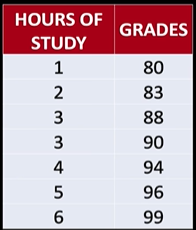 | 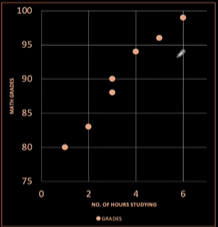 | 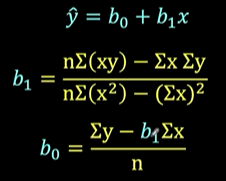

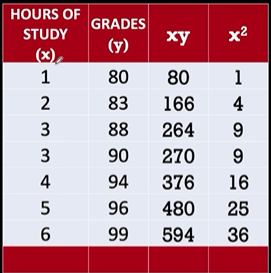 

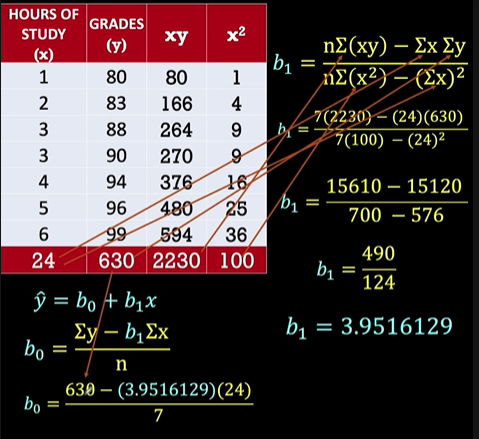 | 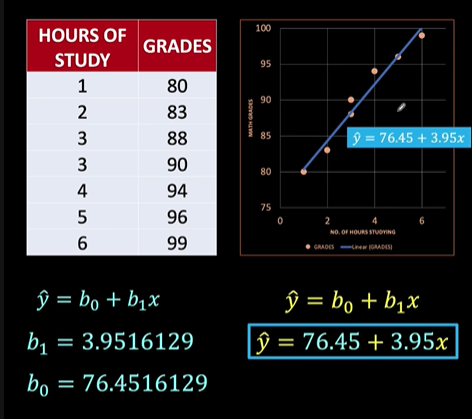

### How Linear regression works

| 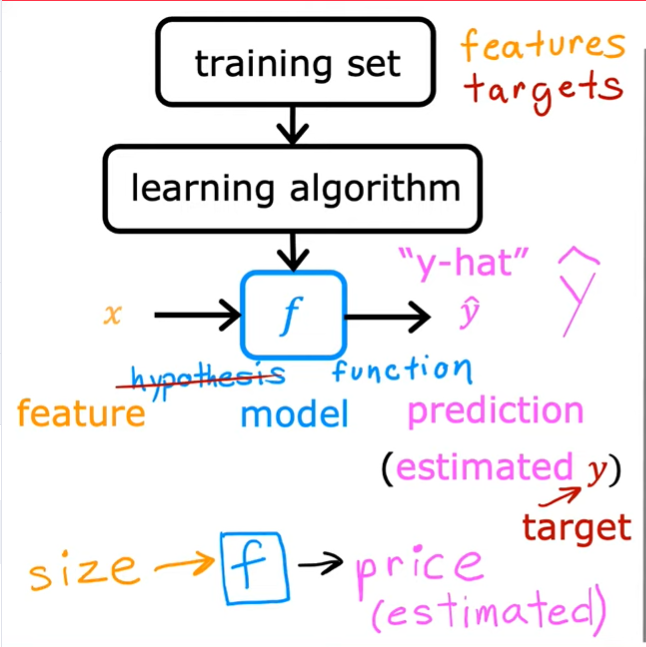 | 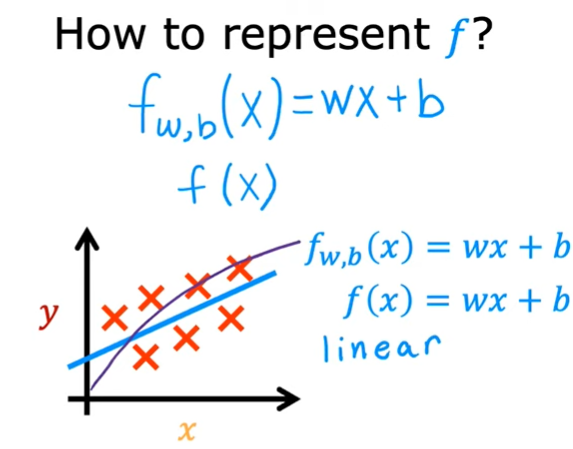 | 
|-----------------------------------|----------------------------------------|

### Cost Function

A `cost function` (also called a loss function) measures how well a machine learning model is performing.

- It calculates the difference between the actual values (from the dataset) and the predicted values (from the model).
- The goal of training is to minimize this cost so the predictions get as close as possible to reality.

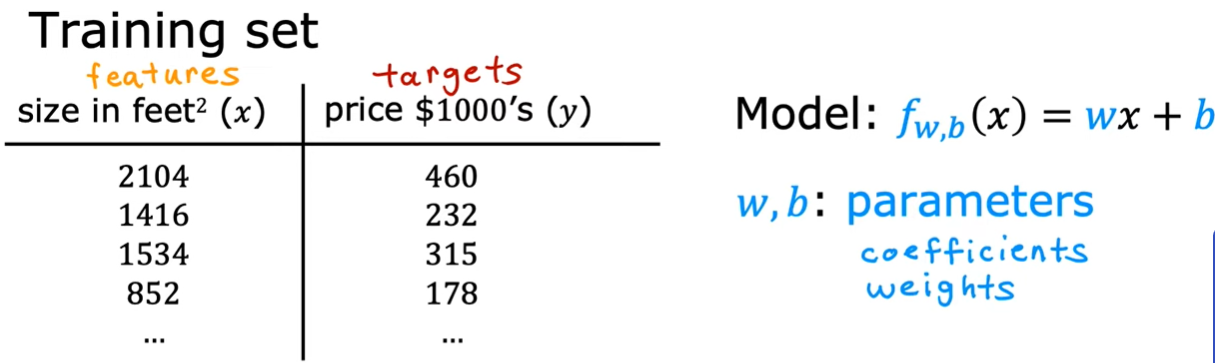




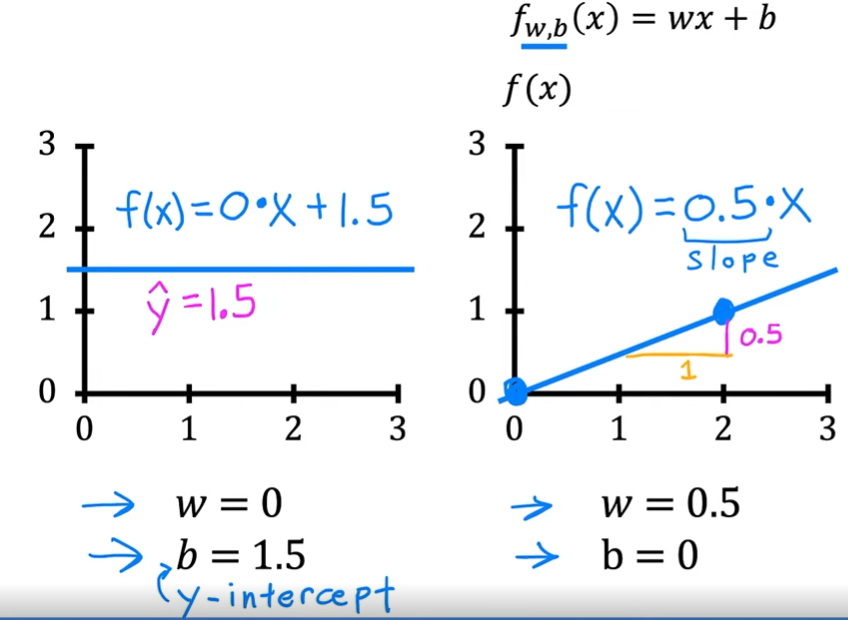

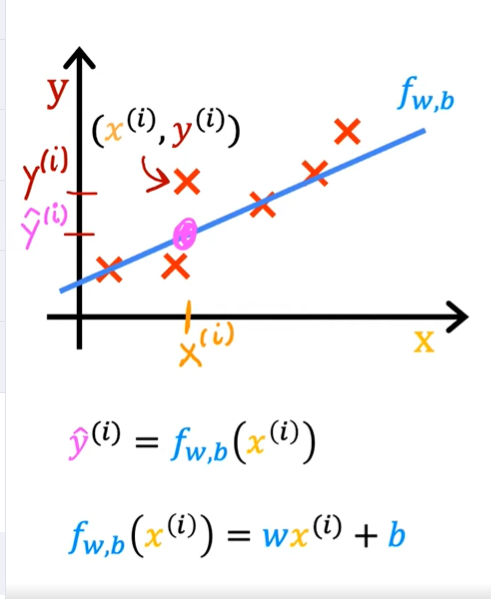

#### import libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv("Salary_dataset.csv")

# Display first rows
print(df.head())


   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


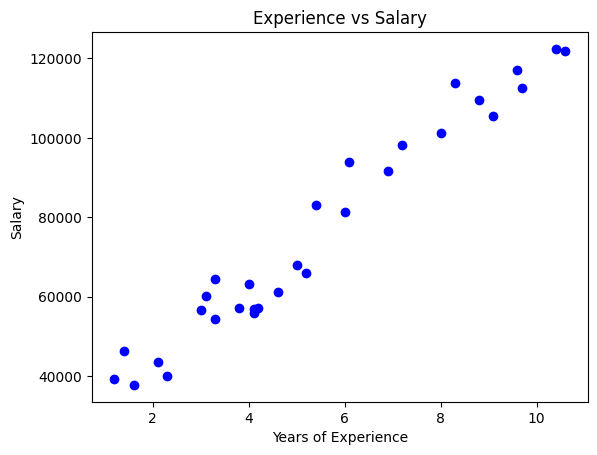

In [3]:
# visualize the data
plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [4]:
# spli the data into features and target
X = df[['YearsExperience']]  # Independent variable
y = df['Salary']             # Dependent variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (β0):", model.intercept_)
print("Slope (β1):", model.coef_[0])


Intercept (β0): 24380.20147947369
Slope (β1): 9423.81532303098


In [6]:
# make predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())


      Actual      Predicted
27  112636.0  115791.210113
15   67939.0   71499.278095
23  113813.0  102597.868661
17   83089.0   75268.804224
8    64446.0   55478.792045


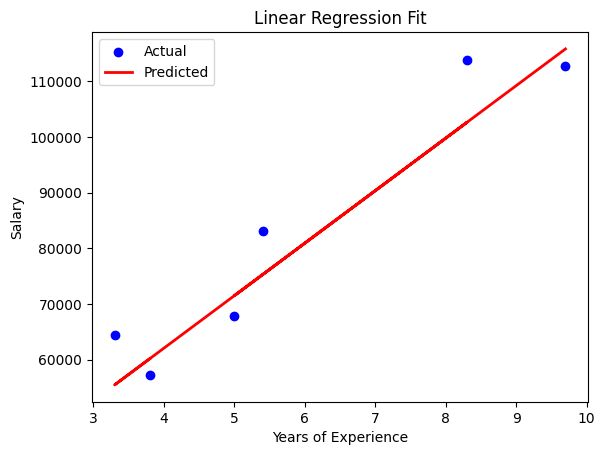

In [7]:
plt.scatter(X_test, y_test, color='blue', label="Actual")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Predicted")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()


## Multiple Linear Regression (MLR)

Multiple Linear Regression is a supervised learning algorithm used to predict a **continuous variable** using **two or more predictors (independent variables)**.  

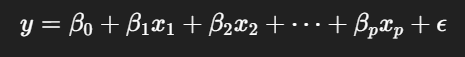

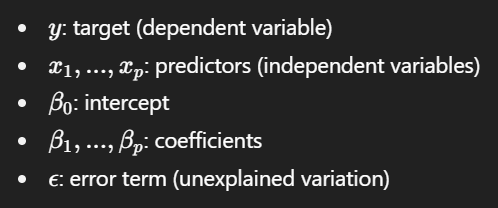

---

### 2. Coefficients in Multiple Linear Regression
Coefficients (β) are the `weights` the model learns. They tell us:

- **Direction (positive/negative effect):**  
  - Positive → an increase in the feature increases \(y\).  
  - Negative → an increase in the feature decreases \(y\).  

- **Magnitude:**  
  - Large coefficient → strong effect.  
  - Small coefficient → weak effect.  

**Example (House Price Prediction):**  

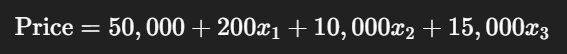

- \(200\): Each additional sq. ft. increases price by \$200 (holding bedrooms & location constant).  
- \(10,000\): Each extra bedroom adds \$10,000.  
- \(15,000\): A better location score adds \$15,000.  

**Key detail:** In multiple regression, coefficients show the effect of **one variable while keeping others constant**.  

### 3. Variance & Variability in MLR
In regression, variability tells us **how much the data is spread out and how well the model explains it**.  

We split variance into parts:  

#### (a) Total Variability (SST)  - Total sum of squares
How much \(y\) varies around its mean:  

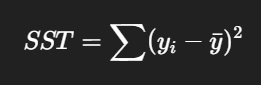

#### (b) Explained Variability (SSR)  - Regression sum of squares
How much of that variability is explained by the regression model:  

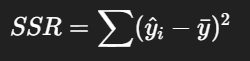

#### (c) Unexplained Variability (SSE)  - Sum of Squared Errors
The error left after regression (residuals):  

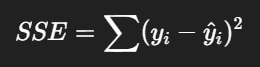 

Relationship:  

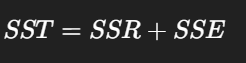


### 4. Connection to \(R^2\)
The proportion of variability explained by the model:  

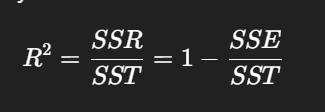

- (R^2 = 0.8\) → Model explains 80% of the variance in \(y\).  
- **Adjusted \(R^2\)** corrects for number of predictors (penalizes unnecessary features).  

### 5. Variance of the Coefficients
Each coefficient has its own **variance (uncertainty):**  

- A **large variance** → coefficient is unstable (sensitive to new data).  
- A **small variance** → coefficient is reliable.  

We use this to compute **standard errors**, **confidence intervals**, and **p-values** to test if coefficients are statistically significant.  

### 6. Assumptions
For coefficients and variance to be valid, we assume:  
1. **Linearity** – relationship between predictors & outcome is linear.  
2. **Independence** – observations are independent.  
3. **Homoscedasticity** – errors have constant variance.  
4. **Normality** – errors are normally distributed.  
5. **No Multicollinearity** – predictors are not too correlated.  

### Summary
- **Coefficients** show how much each predictor affects the target (while holding others constant).  
- **Variance** measures both (1) the variability in \(y\) (explained vs unexplained) and (2) the uncertainty in the coefficients themselves.  
- Together, they tell us **how well the model fits** and **how reliable the feature effects are**.  


### Problem Definition

We are trying to predict house prices in Kenya based on features like number of bedrooms, bathrooms, and size of the house.

We want to know:

What makes a house more expensive?
Can we learn a pattern from past houses?

- Type: Supervised Learning
- Task: Regression
- Target: Price (continuous variable)
- Goal: Learn pricing patterns from historical property data

### Import Libraries

In [340]:
# Data Handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Load Data

In [372]:
df = pd.read_csv("nairobi_house_prices.csv")
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


## Exploratory Data Analysis (EDA)

### Structure inspection

In [373]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    str    
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     str    
 6   Land size     64 non-null     str    
dtypes: float64(2), str(5)
memory usage: 11.3 KB


#### Extract Digits Only for Price

In [374]:
df['Price'].unique()

<StringArray>
['KSh 350 000 000',  'KSh 30 000 000', 'KSh 325 000 000',  'KSh 80 000 000',
  'KSh 25 500 000', 'KSh 300 000 000', 'KSh 160 000 000',   'KSh 9 500 000',
 'KSh 150 000 000',  'KSh 42 000 000', 'KSh 115 300 000', 'KSh 115 000 000',
  'KSh 35 000 000', 'KSh 220 000 000',   'KSh 9 000 000',   'KSh 7 200 000',
 'KSh 200 000 000',  'KSh 68 000 000',  'KSh 28 390 000',  'KSh 17 500 000',
  'KSh 18 000 000',  'KSh 38 000 000',  'KSh 78 000 000',  'KSh 75 000 000',
  'KSh 32 000 000', 'KSh 140 000 000',  'KSh 50 000 000',  'KSh 70 000 000',
  'KSh 12 000 000', 'KSh 322 550 000', 'KSh 380 000 000',   'KSh 8 700 000',
 'KSh 240 000 000',   'KSh 8 000 000',  'KSh 12 600 000',   'KSh 7 000 000',
  'KSh 18 330 000',  'KSh 20 500 000',  'KSh 16 285 499',  'KSh 12 500 000',
  'KSh 23 500 000',  'KSh 33 500 000',  'KSh 16 000 000',  'KSh 21 500 000',
  'KSh 22 500 000',  'KSh 45 000 000',  'KSh 24 000 000',  'KSh 62 500 000',
  'KSh 34 000 000',   'KSh 5 700 000',   'KSh 6 500 000',  'KS

In [375]:
# Extract numbers only
df["Price"] = df["Price"].str.extract(r"(\d+)").astype(float)

In [376]:
df['Price'].unique()

array([350.,  30., 325.,  80.,  25., 300., 160.,   9., 150.,  42., 115.,
        35., 220.,   7., 200.,  68.,  28.,  17.,  18.,  38.,  78.,  75.,
        32., 140.,  50.,  70.,  12., 322., 380.,   8., 240.,  20.,  16.,
        23.,  33.,  21.,  22.,  45.,  24.,  62.,  34.,   5.,   6.,  13.,
       948., 142., 100.,  90.,  39.,  72.,  27.,  40.,  79., 110.,  29.,
        26.,  10.,  99.,  15.,  88., 143.,  95., 180., 250.,  47.,  14.,
         3.,  11.,  60., 120.])

In [377]:
df["House size"].unique()

<StringArray>
[       nan,   '230 m²',   '105 m²',   '280 m²',   '586 m²',    '90 m²',
    '70 m²',  '399 m²"',   '203 m²',   '300 m²',   '423 m²',   '283 m²',
   '385 m²',   '150 m²',    '50 m²',    '57 m²',    '65 m²',  '1 acres',
   '399 m²',   '141 m²',   '260 m²',   '186 m²',    '96 m²',   '159 m²',
    '86 m²',   '302 m²',   '160 m²',   '139 m²',   '202 m²',   '125 m²',
   '223 m²',   '445 m²',   '338 m²',    '48 m²',   '101 m²',   '800 m²',
    '61 m²',        '1',   '168 m²',   '400 m²',   '130 m²',   '116 m²',
   '190 m²',   '600 m²',   '200 m²',    '54 m²',   '110 m²',   '165 m²',
    '60 m²',    '64 m²',    '85 m²',    '75 m²', '2 025 m²',    '95 m²',
   '234 m²']
Length: 55, dtype: str

In [378]:
df["House size"] = df["House size"].astype(str).str.extract(r"(\d+)").astype(float)

In [379]:
df["Land size"] = df["Land size"].astype(str).str.extract(r"(\d+)").astype(float)

In [380]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    float64
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     float64
 6   Land size     64 non-null     float64
dtypes: float64(5), str(2)
memory usage: 11.3 KB


### Distribution of features

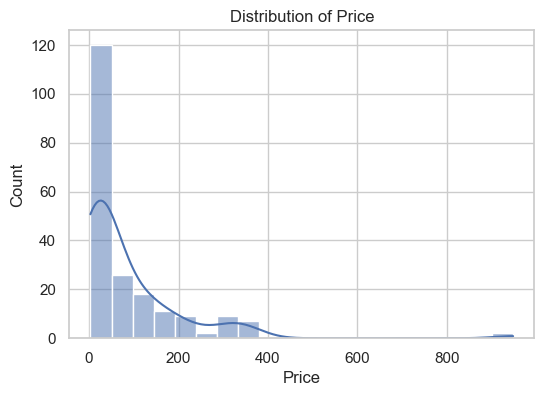

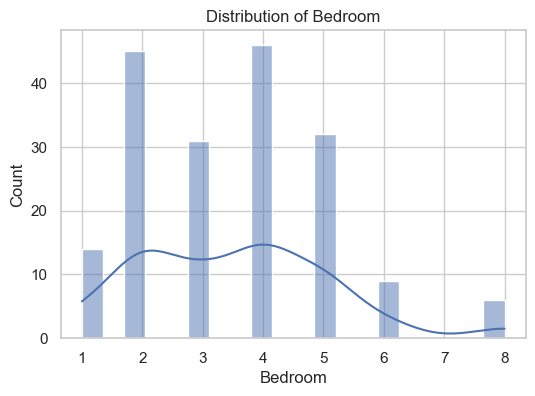

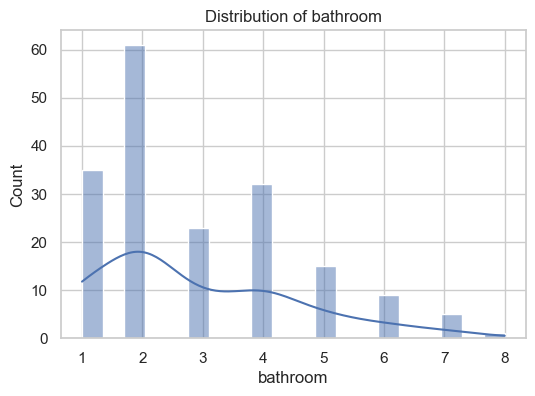

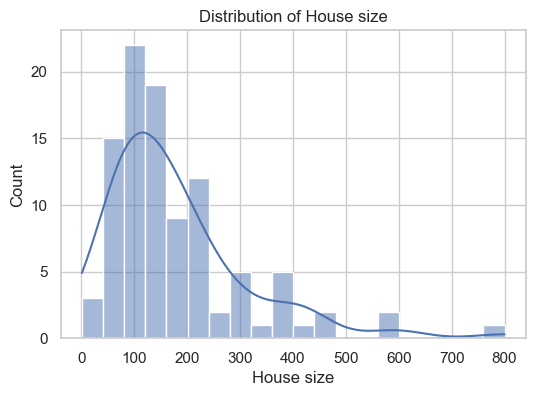

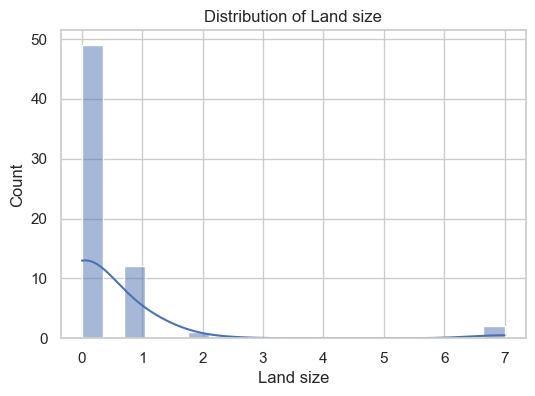

In [381]:
num_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

### Outlier Detection

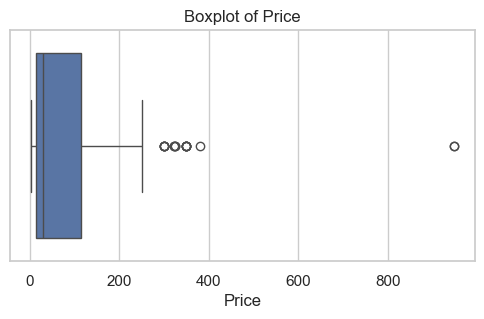

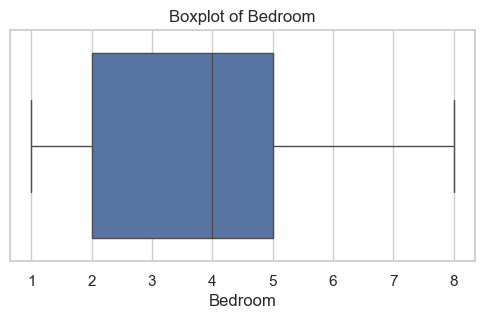

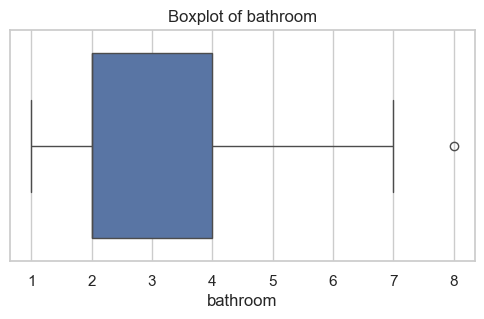

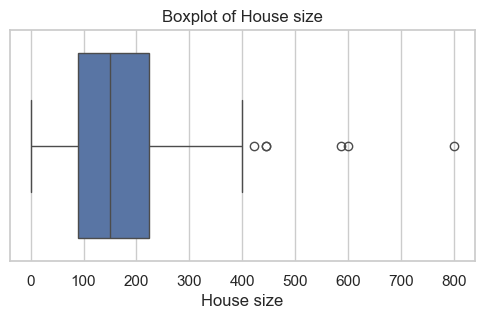

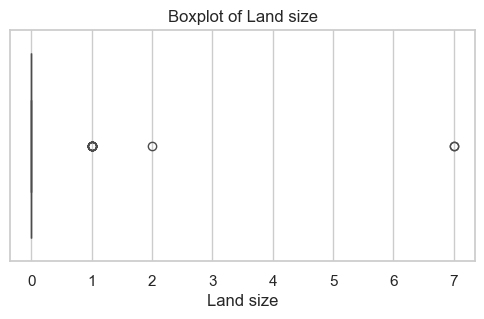

In [382]:
num_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Dealing with the Outliers 

#### Cap (Winsorization)
This keeps data but limits extreme influence.

In [383]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Price'] = df['Price'].clip(lower, upper)

In [384]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    float64
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     float64
 6   Land size     64 non-null     float64
dtypes: float64(5), str(2)
memory usage: 11.3 KB


### Missing values Analysis

In [385]:
df.isnull().sum()

Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64

In [386]:
df.isnull().sum() / len(df) * 100

Price            0.000000
propertyType     0.000000
Location         0.000000
Bedroom         10.294118
bathroom        11.274510
House size      51.470588
Land size       68.627451
dtype: float64

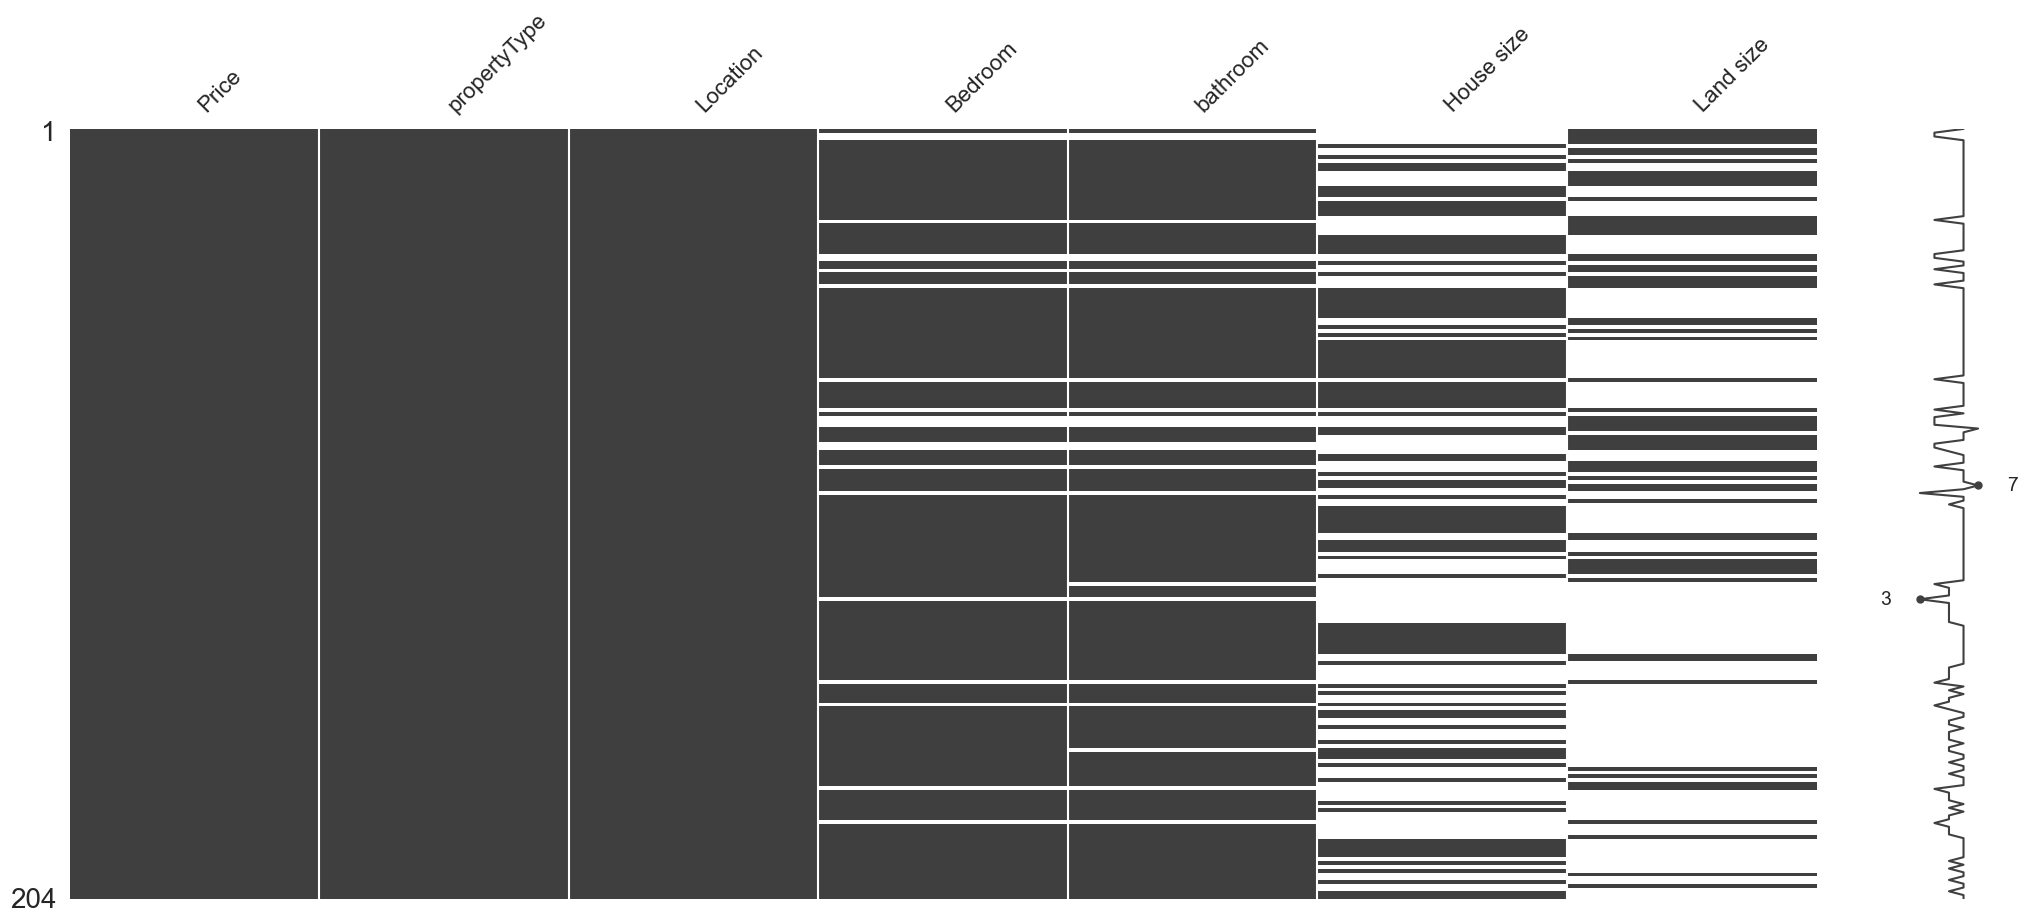

In [387]:
msno.matrix(df)
plt.show()

In [388]:
# Convert missingness into binary flags
df_miss = df.copy()

df_miss['Bedroom_missing'] = df_miss['Bedroom'].isnull().astype(int)
df_miss['Bathroom_missing'] = df_miss['bathroom'].isnull().astype(int)
df_miss['House_size_missing'] = df_miss['House size'].isnull().astype(int)
df_miss['Land_size_missing'] = df_miss['Land size'].isnull().astype(int)

We convert missing values into a classification problem: missing vs not missing.

### Group by property type

Now we check average missingness per category

### Key Insight: Missingness is structured (NOT random)

#### A. Apartment

- **Bedroom_missing** = 0.0 → fully reliable  
- **Bathroom_missing** = 0.02 → almost complete  
- **House_size_missing** = 0.27 → partially missing  
- **Land_size_missing** = 0.91 → mostly irrelevant  

> Apartments are **floor-plan driven**, not land-driven.

- Land size is basically **noise** for this class.

#### B. Commercial Property

- Bedroom = 100% missing  
- Bathroom = 100% missing  
- House size = 100% missing  
- Land size = 0% missing  

> Only **land size matters**.

- Everything else is structurally meaningless.

#### C. Industrial Property

Same pattern as commercial.

- Only **land size is valid**
- Everything else should NOT be imputed as `real values`

#### D. Townhouse

- Bedroom_missing = 0  
- Bathroom_missing = 0  
- House_size_missing = 0.72 (high!)  
- Land_size_missing = 0.54  

> Rooms exist and are reliable  
- Size variables are inconsistently recorded  

> This is a **partially structured residential type**

#### E. Townhouse (typo)

- House_size_missing = 100%  
- Land_size_missing = 0%  

### Important insight:
This is NOT just a typo issue anymore.

It behaves like a **different data subgroup**.

> We must fix the label first or risk model distortion.

#### F. Vacant Land

- Bedroom = 100% missing  
- Bathroom = 100% missing  
- House size = 94% missing  
- Land size = 16% missing  

> Land is the **primary feature**
- Everything else is irrelevant

### What this means for Linear Regression

Linear regression assumes:

> Numeric relationships are meaningful and consistent

So we must ensure:

#### Avoid:
- Fake values in irrelevant fields  
- Global mean imputation  
- Treating all property types equally  

#### Use:
- Group-aware imputation  
- “Not applicable” encoding  
- Missing indicators  

This table shows that missing data is structured, not random.

For example, vacant land has no bedrooms by definition, while apartments rarely have land size.

This helps us decide how to clean and engineer features before building our model.

### Fixing the dataset 

We do NOT use one global imputation method.

##### Fix data quality issue first

In [389]:
# correct categories first:
df['propertyType'] = df['propertyType'].replace({'Townhuse': 'Townhouse'})

#### Inspect categories first

Always start by seeing what’s actually inside:

In [390]:
df['propertyType'].value_counts()

propertyType
Apartment              104
Townhouse               79
Vacant Land             19
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

#### Drop Rare Property Types

In [391]:
df = df[~df["propertyType"].isin(["Commercial Property", "Industrial Property"])]

In [392]:
df['propertyType'].value_counts()

propertyType
Apartment      104
Townhouse       79
Vacant Land     19
Name: count, dtype: int64

In [393]:
df.isnull().sum()

Price             0
propertyType      0
Location          0
Bedroom          19
bathroom         21
House size      103
Land size       140
dtype: int64

#### Handle features based on usefulness
A. Bedroom & Bathroom (LOW missingness - safe to impute)

In [394]:
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,266.5,Townhouse,Runda,4.0,4.0,NaN,0.0
1,30.0,Vacant Land,Karen,NaN,NaN,NaN,0.0
2,266.5,Vacant Land,Westlands,NaN,NaN,NaN,0.0
3,80.0,Townhouse,Kitisuru,5.0,5.0,NaN,0.0
4,25.0,Apartment,Kileleshwa,4.0,4.0,230.0,NaN


#### House Size (VERY IMPORTANT feature)

50% missing - but still valuable

In [397]:
df["House size"] = df.groupby("propertyType")["House size"].transform(
    lambda x: x.fillna(x.median())
)

#### Land Size - HIGH missingness

Keep it, but create a missing indicator

In [398]:
df["Land size_missing"] = df["Land size"].isna().astype(int)

df["Land size"] = df.groupby("propertyType")["Land size"].transform(
    lambda x: x.fillna(x.median())
)

In [399]:
df["Land size"].dtype

dtype('float64')

In [400]:
df['Land size'].unique()

array([0., 1., 2., 7.])

In [401]:
df["Land size_missing"] = df["Land size"].isna().astype(int)

df["Land size"] = df.groupby("propertyType")["Land size"].transform(
    lambda x: x.fillna(x.median())
)

In [402]:
df.info()

<class 'pandas.DataFrame'>
Index: 202 entries, 0 to 203
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              202 non-null    float64
 1   propertyType       202 non-null    str    
 2   Location           202 non-null    str    
 3   Bedroom            183 non-null    float64
 4   bathroom           181 non-null    float64
 5   House size         202 non-null    float64
 6   Land size          202 non-null    float64
 7   Land size_missing  202 non-null    int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 14.2 KB


#### View Unique Categories

In [404]:
df["propertyType"].unique()

<StringArray>
['Townhouse', 'Vacant Land', 'Apartment']
Length: 3, dtype: str

In [186]:
df["propertyType"].value_counts()

propertyType
Apartment      104
Townhouse       79
Vacant Land     19
Name: count, dtype: int64

In [187]:
df["Location"].unique()

<StringArray>
[         'Runda',          'Karen',      'Westlands',       'Kitisuru',
     'Kileleshwa',       'Kilimani',        'Thigiri',          'Kyuna',
          'Nyari',      'Lavington',        'Loresho',      'Parklands',
      'Riverside', 'Muthaiga North',        'Rosslyn',       'Muthaiga',
         'Kabete',          'Thome',    'Kiambu Road',  'Ongata Rongai',
   'Lower Kabete',       'Ngong Rd',   'Nairobi West',       'Syokimau',
       'Waithaka']
Length: 25, dtype: str

In [188]:
df["Location"].value_counts()

Location
Kilimani          36
Lavington         34
Westlands         27
Kileleshwa        22
Runda             20
Karen             14
Kitisuru           9
Riverside          6
Nyari              5
Loresho            5
Kiambu Road        4
Thigiri            3
Rosslyn            3
Ngong Rd           2
Nairobi West       2
Kyuna              1
Parklands          1
Muthaiga North     1
Muthaiga           1
Kabete             1
Thome              1
Ongata Rongai      1
Lower Kabete       1
Syokimau           1
Waithaka           1
Name: count, dtype: int64

### Encoding

#### propertyType - One-Hot Encoding

In [405]:
df = pd.get_dummies(df, columns=["propertyType"], drop_first=True)

In [406]:
df.info()   

<class 'pandas.DataFrame'>
Index: 202 entries, 0 to 203
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     202 non-null    float64
 1   Location                  202 non-null    str    
 2   Bedroom                   183 non-null    float64
 3   bathroom                  181 non-null    float64
 4   House size                202 non-null    float64
 5   Land size                 202 non-null    float64
 6   Land size_missing         202 non-null    int64  
 7   propertyType_Townhouse    202 non-null    bool   
 8   propertyType_Vacant Land  202 non-null    bool   
dtypes: bool(2), float64(5), int64(1), str(1)
memory usage: 13.0 KB


In [407]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

#### Location - Frequency Encoding

In [408]:
# Create frequency map
location_freq = df["Location"].value_counts(normalize=True)

In [409]:
# Map into dataset
df["Location_encoded"] = df["Location"].map(location_freq)

In [410]:
# Drop original column
df = df.drop("Location", axis=1)

##### Why this is powerful (important insight)

Location importance = frequency in market data

> This captures:

- demand areas (high frequency)
- rare luxury areas (low frequency)

##### Why NOT one-hot for Location?

Because:

- 25+ columns → high dimensionality
- many locations have 1 sample - noise
- Ridge/Lasso would struggle with sparse data

In [411]:
df.info()

<class 'pandas.DataFrame'>
Index: 202 entries, 0 to 203
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     202 non-null    float64
 1   Bedroom                   183 non-null    float64
 2   bathroom                  181 non-null    float64
 3   House size                202 non-null    float64
 4   Land size                 202 non-null    float64
 5   Land size_missing         202 non-null    int64  
 6   propertyType_Townhouse    202 non-null    int64  
 7   propertyType_Vacant Land  202 non-null    int64  
 8   Location_encoded          202 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 15.8 KB


In [325]:
df["Bedroom"] = df["Bedroom"].fillna(df["Bedroom"].median())
df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())

In [326]:
df.isnull().sum()

Price                       0
Bedroom                     0
bathroom                    0
House size                  0
Land size                   0
Land size_missing           0
propertyType_Townhouse      0
propertyType_Vacant Land    0
Location_encoded            0
dtype: int64

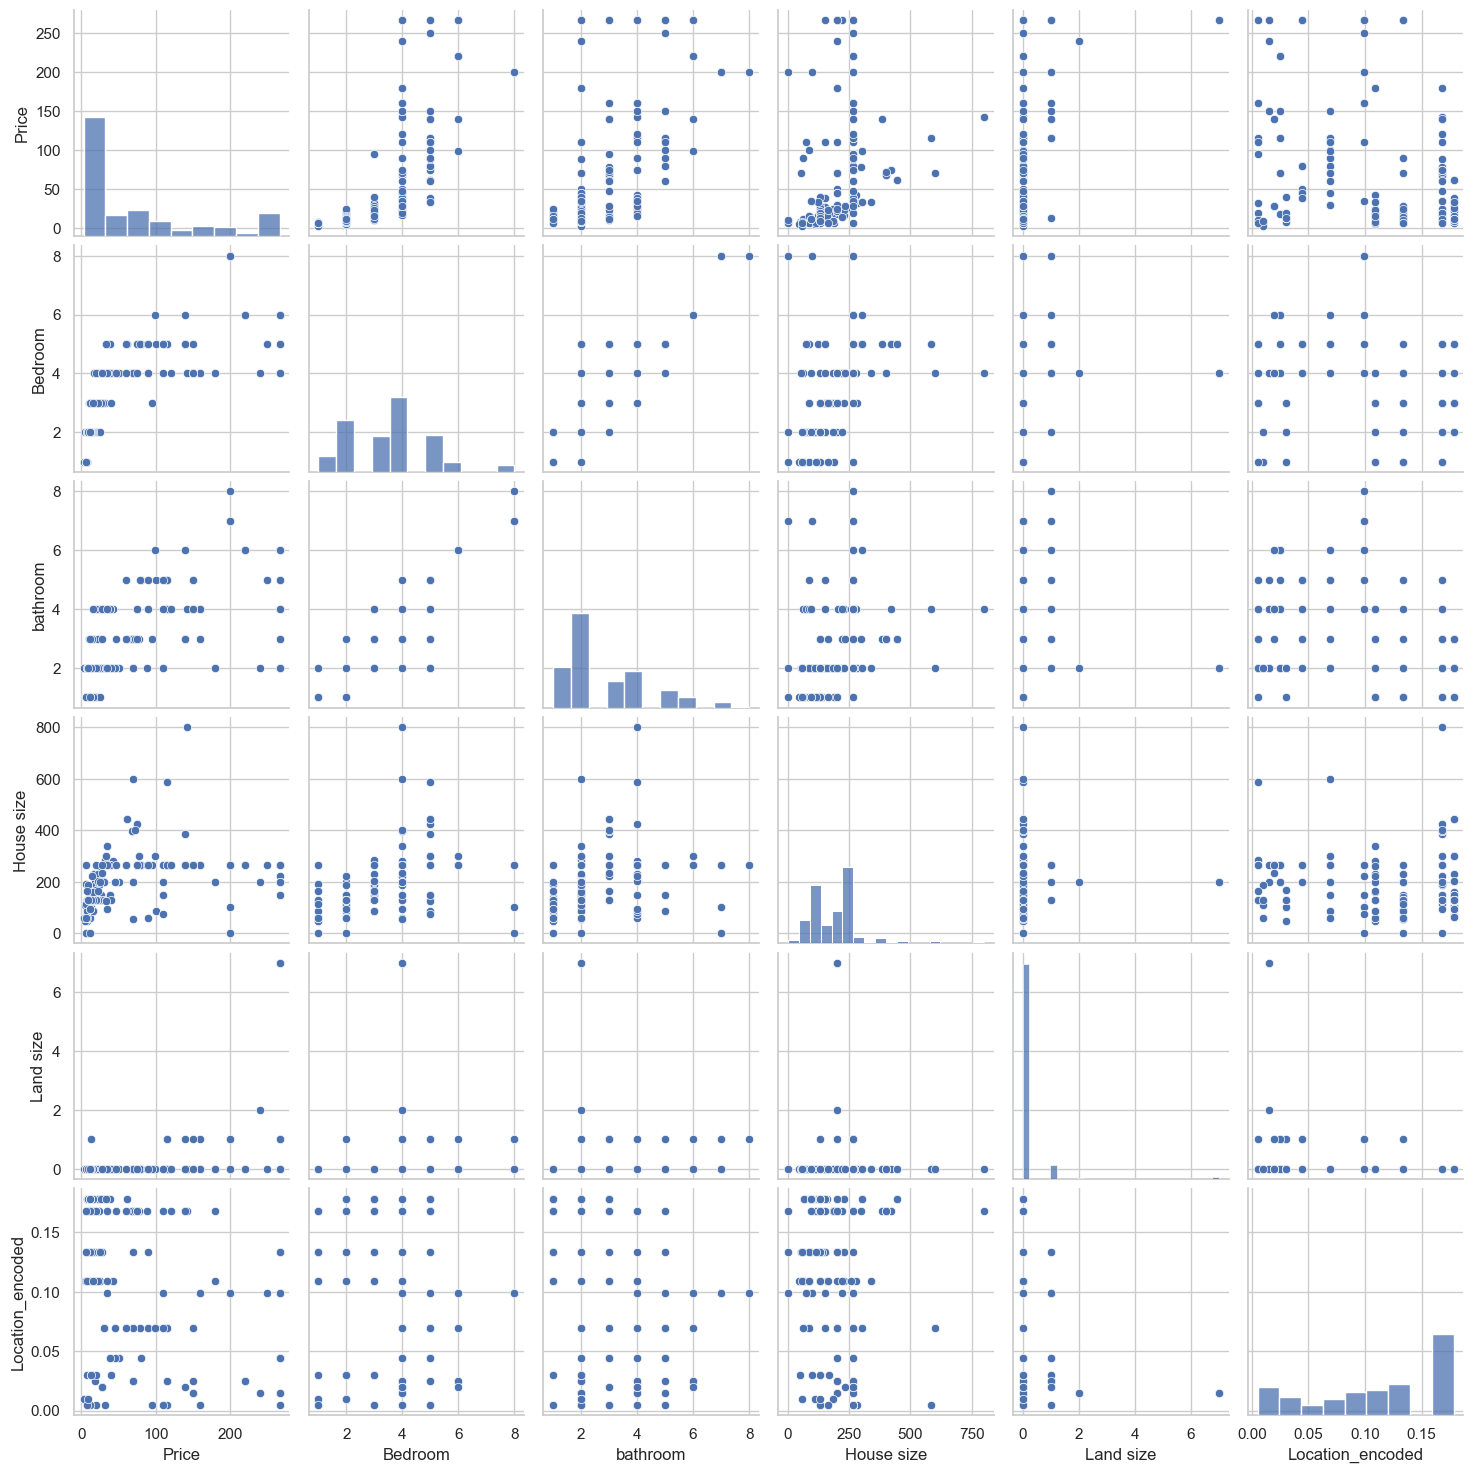

In [327]:
import seaborn as sns

features = [
    "Price",
    "Bedroom",
    "bathroom",
    "House size",
    "Land size",
    "Location_encoded"
]

sns.pairplot(df[features])

In [328]:
df.corr()["Price"].sort_values(ascending=False)

Price                       1.000000
Bedroom                     0.659654
bathroom                    0.620106
propertyType_Townhouse      0.572469
House size                  0.384594
Land size                   0.346272
propertyType_Vacant Land    0.270108
Location_encoded           -0.303956
Land size_missing          -0.504367
Name: Price, dtype: float64

Text(0.5, 1.0, 'Correlation Heatmap')

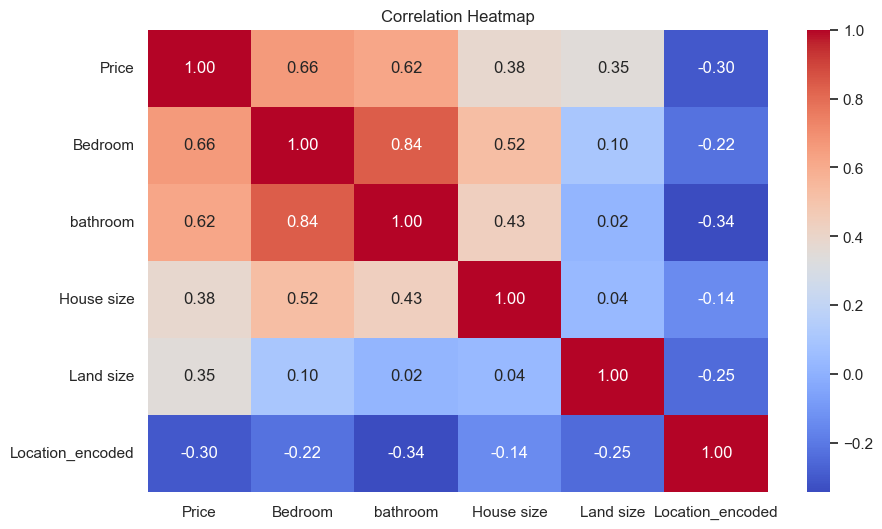

In [329]:
# correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

#### Define Features and Target

In [330]:
X = df.drop("Price", axis=1)
y = df["Price"]

#### Train-Test Split

In [331]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Scaling (VERY IMPORTANT)

We scale because:

- Linear models are sensitive to feature magnitude
- Polynomial features explode in scale
- Ridge/Lasso depend heavily on scale

In [332]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Baseline: Linear Regression Pipeline

In [333]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

y_pred_lin = lin_model.predict(X_test_scaled)

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("Linear R2:", r2_score(y_test, y_pred_lin))

Linear RMSE: 51.67889940709203
Linear R2: 0.6392736243914092


In [334]:
# Compute Residuals
residuals = y_test - y_pred_lin

##### Residual vs Predicted Plot

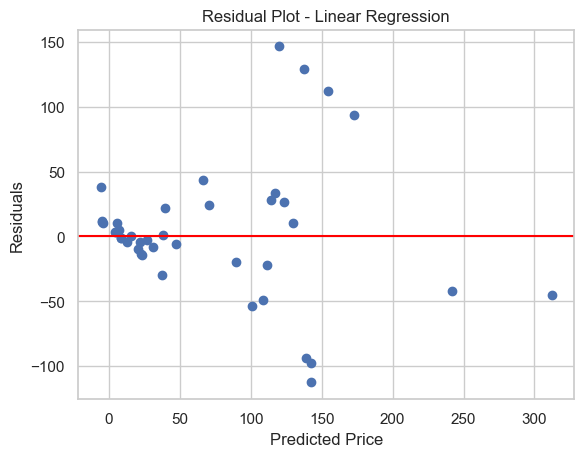

In [335]:
plt.scatter(y_pred_lin, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

There is an increasing error at higher predicted values

On the right side (high predicted prices):

residuals become more spread out
some very large positive/negative errors

This is called:

> Heteroscedasticity

- (more error as price increases)

The residual plot shows non-random structure and increasing variance at higher predicted values. This indicates that the linear model is not fully capturing the underlying relationships in the data, suggesting the presence of non-linear effects and potential heteroscedasticity.

#### Polynomial Regression Pipeline

We must include scaling + polynomial expansion.

In [336]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("Poly RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("Poly R2:", r2_score(y_test, y_pred_poly))

Poly RMSE: 60.398824398968614
Poly R2: 0.5072707349645516


#### Ridge Regression (Regularization)

In [337]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge RMSE: 51.572562075311886
Ridge R2: 0.6407565977621513


#### Lasso Regression (Feature Selection)

In [338]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso RMSE: 51.6777307378921
Lasso R2: 0.639289939175312


#### Final Comparison Table

In [339]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    "R2": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results

,Model,RMSE,R2
0,Linear,51.678899,0.639274
1,Polynomial,60.398824,0.507271
2,Ridge,51.572562,0.640757
3,Lasso,51.677731,0.639290
